# Lets check and improve on the permutation test

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Initialize empty 10×10 matrix
B = np.zeros((10, 10), dtype=int)

# Fill the specified coordinates
B[7, 6] = 60
B[6, 5] = 35
B[6, 6] = 10
B[5, 5] = 5

print("Total =", B.sum())
print(B)

RED = np.array([0, 355.6, 711.1, 1066.7, 1422.2, 1777.8, 2133.3, 2488.9, 2844.4, 3200.0])
GREEN = np.array([0, 222.2, 444.4, 666.7, 888.9, 1111.1, 1333.3, 1555.6, 1777.8, 2000.0])
cmap="viridis"




Total = 110
[[ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  5  0  0  0  0]
 [ 0  0  0  0  0 35 10  0  0  0]
 [ 0  0  0  0  0  0 60  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]]


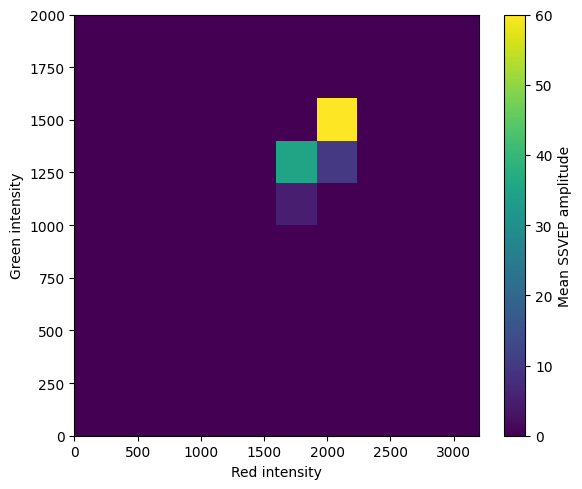

In [3]:
plt.figure(figsize=(6, 5))

# Heatmap with optional color scale control
plt.imshow(
    B,
    origin="lower",
    cmap=cmap,
    extent=[RED.min(), RED.max(), GREEN.min(), GREEN.max()],
    aspect="auto"
)
plt.colorbar(label="Mean SSVEP amplitude")

plt.xlabel("Red intensity")
plt.ylabel("Green intensity")
plt.tight_layout()
plt.show()

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_permuted_B_grid(B_norm, nPerm=5, RED=None, GREEN=None, cmap="viridis", rotation = True):
    """
    Plot a grid of permuted behavioral maps (2D toroidal shifts).
    """
    if RED is None:
        RED = np.array([0, 355.6, 711.1, 1066.7, 1422.2, 1777.8, 2133.3, 2488.9, 2844.4, 3200.0])
    if GREEN is None:
        GREEN = np.array([0, 222.2, 444.4, 666.7, 888.9, 1111.1, 1333.3, 1555.6, 1777.8, 2000.0])

    cols = min(nPerm, 5)
    rows = int(np.ceil(nPerm / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)

    for i in range(nPerm):
        shiftX = np.random.randint(0, 100)
        shiftY = np.random.randint(0, 100)
        if rotation:
        # Random rotation (0, 90, 180, 270 degrees)
            k = np.random.randint(0, 4)

        # Apply rotation first, then shift
            B_perm = np.rot90(B_norm, k=k)
            B_perm = np.roll(B_perm, shift=(shiftX, shiftY), axis=(0, 1))
        else:
            B_perm = np.roll(B_norm, shift=(shiftX, shiftY), axis=(0, 1))
        ax = axes[i]
        im = ax.imshow(
            B_perm,
            origin="lower",
            cmap=cmap,
            extent=[RED.min(), RED.max(), GREEN.min(), GREEN.max()],
            aspect="auto"
        )
        ax.set_title(f"Shift ({shiftX}, {shiftY})")
        ax.set_xlabel("Red")
        ax.set_ylabel("Green")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


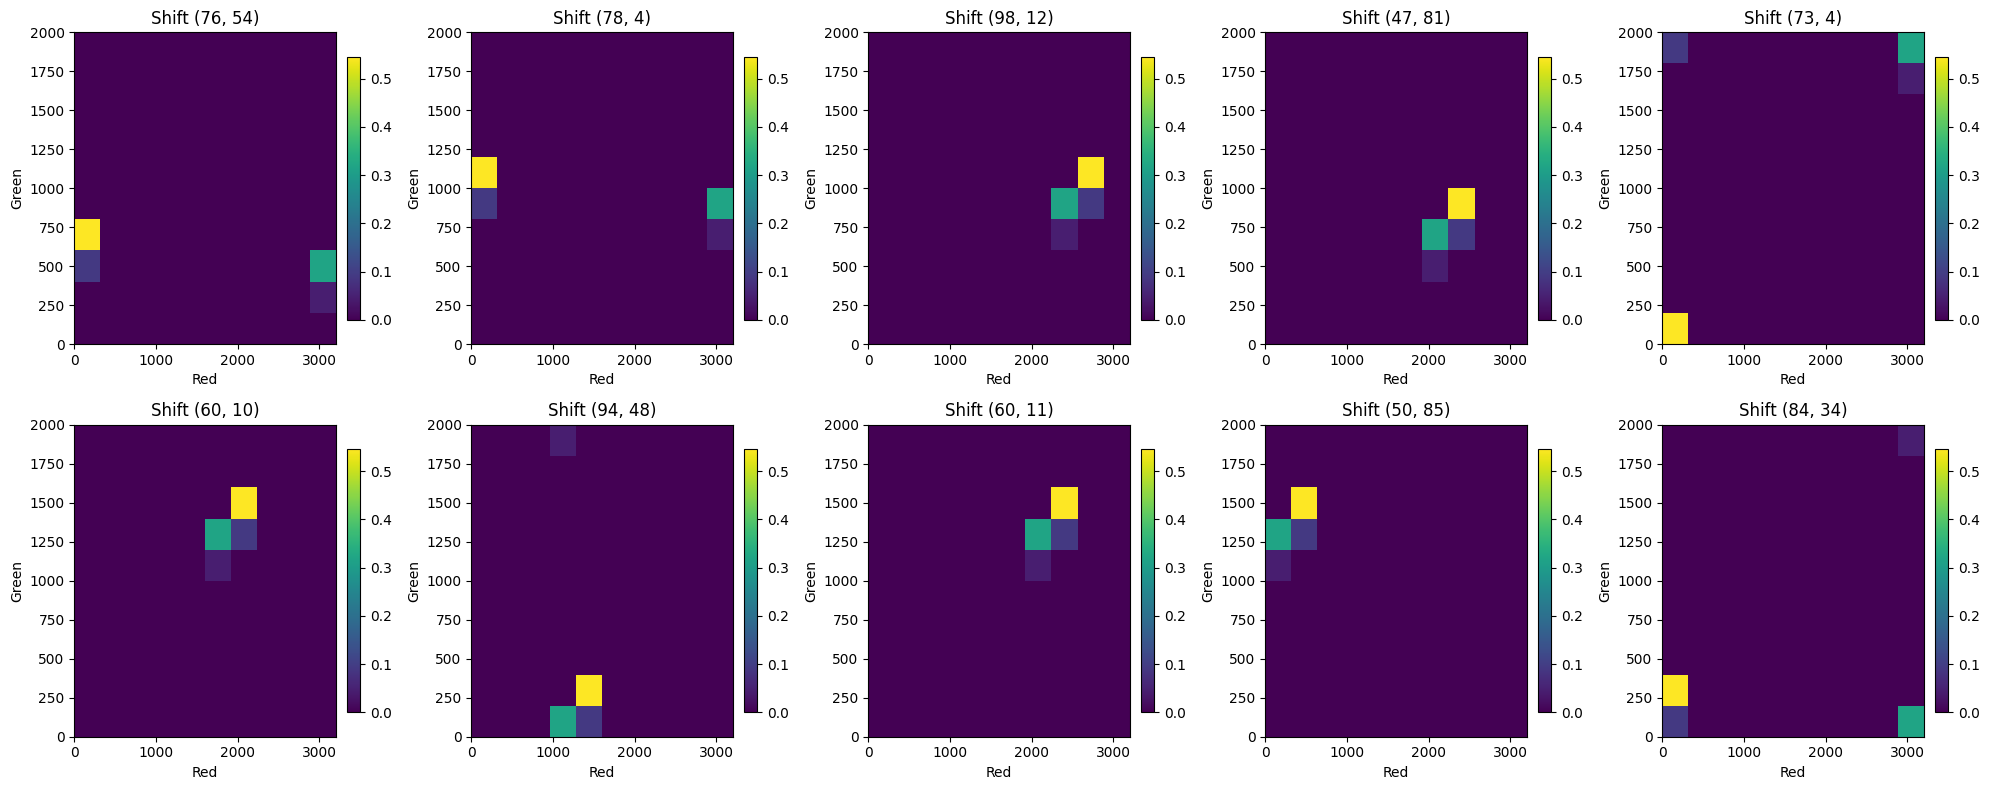

In [14]:
totalB = B.sum()
B_norm = B / totalB

plot_permuted_B_grid(B_norm, nPerm=10, RED=RED, GREEN=GREEN, rotation=False)